# Gene Expression in Tumor Patients: a Differential Look at Microarray Data

How much does gene expression vary between tumoral samples and normal samples? Can we find a pattern in which gene's expressions are upregulated or downregulated in tumor patients? Starting with a sample of 16 patients, 8 tumoral and 8 healthy, we look at the differences in gene expression for 36,000 genes to observe potential genes for study. The dataset contains microarray data for all 36,000 genes for 16 sujects, in two categories 'normal' and 'tumoral'. I am examining the dataset looking for patterns in the differential microarray expression. First, I perform permutation tests on the genes to find those that are significantly different between the two groups, and then looked at patterns within that data.

I found 9,039 genes with a significant difference in microarray expression, and of those genes, ribosomal genes to be overrepresented. Several humdred ribosome-associated genes were found to be downregulated in tumoral patients as opposed to normal patients. This data was compared to literature studying metabolic disorders, which found that ribosomal genes were commonly upregulated in insulin-resistant latino patients. 

In [2]:
import numpy as np
import pandas as pd

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight') #this is the plot style we use in my data science class, and I'm just used to it

import seaborn as sns
sns.set_style('whitegrid') #common plot style for seaborn as well 

import matplotlib.patches as mpatches

Importing numpy and pandas for data analysis, matplotlib and seaborn for plotting, and matplotlib patches so I can customize legends for data visualization.

In [699]:
#load in data; no need to drop any of the data 
breast1 = pd.read_csv('Breast_GSE33447.csv')

In [27]:
# saving sample names in case I need them, since I'm likely going to drop them for a while
breast1_sample_names = breast1['samples']

### Preparing Data for Analysis
Generating differential data in the two categories for means and standard deviations, as well as separating the dataset into 'tumoral' and 'normal' data.

In [700]:
# finding average gene expression, split by normal vs tumoral samples
breast1_averages = breast1.groupby('type').mean(numeric_only = True).T.reset_index().\
    rename(columns = {'index':'gene'}).rename_axis(None, axis = 1)

# finding the standard deviation of gene expression, split by normal vs tumoral samples
breast1_std = breast1.groupby('type').std(numeric_only = True).T.reset_index().\
    rename(columns = {'index':'gene'}).rename_axis(None, axis = 1)

In [29]:
# make dataframes containing gene expression separated by normal or tumoral samples
breast1_tumors = breast1[breast1['type'] == 'tumoral'].drop(columns = ['samples', 'type']).T.reset_index().\
    rename(columns = {'index':'gene'})

breast1_normal = breast1[breast1['type'] == 'normal'].drop(columns = ['samples', 'type']).T.reset_index().\
    rename(columns = {'index':'gene'})

Here, I find the difference in means between the normal and tumoral samples. Notably, I took the absolute value of the differences so I don't have any negative values, as this will be important for later analysis. The difference in means will be the bases for this portion of analysis. 

In [30]:
# find gene expression difference between normal and tumoral by gene

gene_exp_difference = pd.DataFrame(
    {'gene': list(breast1_averages['gene']),
     'exp_difference': list(abs(breast1_averages['normal'] - breast1_averages['tumoral']))})
gene_exp_difference.sort_values(by = 'exp_difference', ascending = False)

,gene,exp_difference
2620,NM_000936,5.538292
24118,NM_002909,5.371908
8768,NM_005747,5.371114
22191,NM_002427,5.146489
2923,NM_152997,5.086583
...,...,...
36053,lincRNA:chr21:30766179-30790004_R,0.000043
14316,lincRNA:chr8:90618650-90619014_R,0.000039
12876,NM_002100,0.000027
21225,ENST00000316506,0.000025


### Graphical Analysis to Determine Analytical Approach 
Using the difference in means calculated above, we can visualize how much the raw gene expression data can differ. Notably, microarry data does not have units, and only has value as it relates to other values of microarray data.

Here, I generate a side-by-side boxplots of the genes wiht the greatest raw difference in gene expression. 

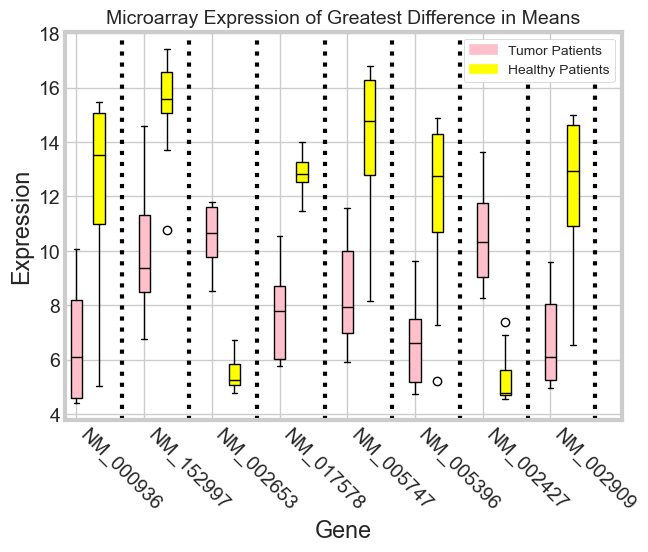

In [31]:
#get genes that have large differences in expression 
large_diff = gene_exp_difference[gene_exp_difference.exp_difference >= 5]['gene'].values

large_diff_tumors = breast1_tumors.set_index('gene').T[large_diff]
large_diff_normal = breast1_normal.set_index('gene').T[large_diff]

fig, ax = plt.subplots()

tumors = ax.boxplot(large_diff_tumors, patch_artist=True, positions=np.arange(1,25,3))

normal = ax.boxplot(large_diff_normal, patch_artist=True, positions=np.arange(2,26,3))

ax.set_xticks(ticks = np.arange(1,25,3), labels = large_diff_tumors.columns, rotation = 315, ha = 'left')

pink_patch = mpatches.Patch(color='pink', label='Tumor Patients')
yellow_patch = mpatches.Patch(color='yellow', label='Healthy Patients')

for i in np.arange(3, 27, 3):
    ax.axvline(i, color='k', lw = 3, ls = ':')
    
ax.legend(handles = [pink_patch, yellow_patch], fontsize = 10, framealpha = 1)

ax.xaxis.grid(True)

for patch in tumors['boxes']:
    patch.set(facecolor = 'pink')

for patch in tumors['medians']:
    patch.set(color = 'black')
        
for patch in normal['boxes']:
    patch.set(facecolor = 'yellow')

for patch in normal['medians']:
    patch.set(color = 'black')


ax.set_xlabel('Gene')
ax.set_ylabel('Expression')
ax.set_title('Microarray Expression of Greatest Difference in Means', fontsize = 14);

It seems visually obvious see that these differences are significant, but how can we prove it mathematically? And what happens if we look at genes with very low difference in expression?

Text(0.5, 1.0, 'Microarray Expression of Least Difference in Means')

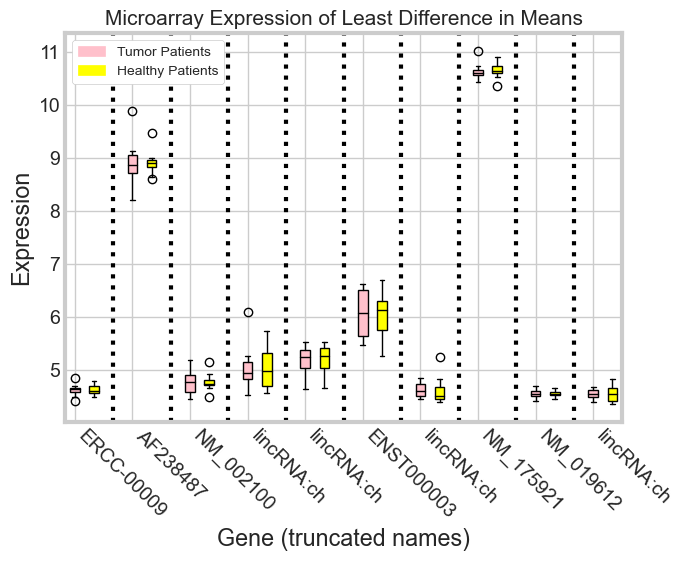

In [552]:
#get genes that have small differences in expression 
small_diff = gene_exp_difference[gene_exp_difference.exp_difference < 0.0001]['gene'].values

small_diff_tumors = breast1_tumors.set_index('gene').T[small_diff]
small_diff_normal = breast1_normal.set_index('gene').T[small_diff]

fig, ax = plt.subplots()

tumors = ax.boxplot(small_diff_tumors, patch_artist=True, positions=np.arange(1,31,3))

normal = ax.boxplot(small_diff_normal, patch_artist=True, positions=np.arange(2,32,3))

labels = [i[:10] for i in small_diff_tumors.columns]

ax.set_xticks(ticks = np.arange(1,31,3), labels = labels, rotation = 315, ha = 'left')

pink_patch = mpatches.Patch(color='pink', label='Tumor Patients')
yellow_patch = mpatches.Patch(color='yellow', label='Healthy Patients')

for i in np.arange(3, 30, 3):
    ax.axvline(i, color='k', lw = 3, ls = ':')
    
ax.legend(handles = [pink_patch, yellow_patch], fontsize = 10, framealpha = 1)

ax.xaxis.grid(True)

for patch in tumors['boxes']:
    patch.set(facecolor = 'pink')

for patch in tumors['medians']:
    patch.set(color = 'black')
        
for patch in normal['boxes']:
    patch.set(facecolor = 'yellow')

for patch in normal['medians']:
    patch.set(color = 'black')


ax.set_xlabel('Gene (truncated names)')
ax.set_ylabel('Expression')
ax.set_title('Microarray Expression of Least Difference in Means', fontsize = 15)

It does seem like these genes have very small differences in their means, but it is much more difficult to see for genes with very small differences. 

Notably, looking at the above graphs, we can see that the genes that have the biggest difference in expression between the normal and tumoral patients also have the greatest variation within the normal and tumoral groups. So, instead of simply looking at the raw differences in means, we need to decide on a threshold of significance to determine if these differences are meaningful. 

Since we only have 8 samples in each group, we cannot do any of the normal hypothesis or A/B testing that would require we could assume normality of the data. Thus, we need a different approach. I decided to perform permutation tests to determine the likelihood that the observed difference was due to random chance. Then, we can look at the genes for which their difference of means has less than a 5% chance of occuring due to random variation. 

In [387]:
# let's perform a permutation test to determine if the difference between means is meaningful
# create a function to shuffle values
# we'll use a significance level of alpha = 0.05

def get_shuffled_means(column_labels, column_values):
    '''returns the difference in shuffled means for a specific gene for permutation test'''
    shuffled_values = column_values.sample(len(column_values)).values
    df = pd.DataFrame({'groups': column_labels, 'shuff_vals': shuffled_values})
    df = df.groupby('groups').mean()
    difference = df.iloc[0,0] - df.iloc[1,0]
    
    return difference

P-value: 0.3364


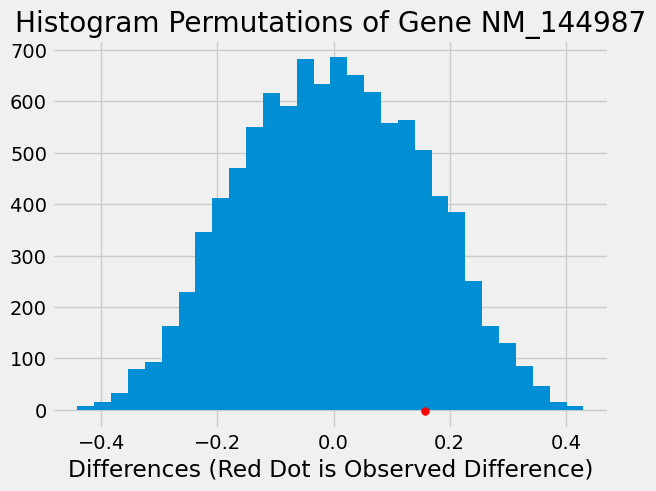

In [410]:
# example of procedure to determine a significant difference
means = np.array([])
obs_diff = gene_exp_difference[gene_exp_difference['gene'] == 'NM_144987']['exp_difference'].values

for i in np.arange(10000):
    one_mean = get_shuffled_means(breast1.type, breast1['NM_144987'])
    means = np.append(means, one_mean)

plt.hist(means, bins = 30)
plt.scatter(obs_diff, -2, color='red', s=30)

plt.title('Histogram Permutations of Gene NM_144987')
plt.xlabel('Differences (Red Dot is Observed Difference)')

# two-sided test
pval = 2*sum(means >= obs_diff)/10000
print('P-value:', pval)

We can see from our p-value that the observed difference has an approximately 33% of occurring due to normal variation. Visually, we can see that the observed difference is well within the bulk of the randomly generated differences. This one isn't significant, so let's see if we can find one that is.

P-value: 0.006


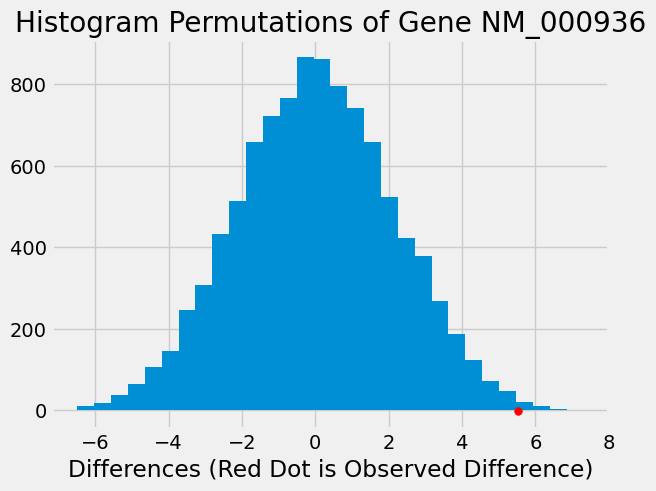

In [411]:
# Let's try it for gene NM_000936, which had one of the highest differences in means
means = np.array([])
obs_diff = gene_exp_difference[gene_exp_difference['gene'] == 'NM_000936']['exp_difference'].values

for i in np.arange(10000):
    one_mean = get_shuffled_means(breast1.type, breast1['NM_000936'])
    means = np.append(means, one_mean)

plt.hist(means, bins = 30)
plt.scatter(obs_diff, -2, color='red', s=30)
plt.title('Histogram Permutations of Gene NM_000936')
plt.xlabel('Differences (Red Dot is Observed Difference)')

# two-sided test
pval = 2*sum(means >= obs_diff)/10000
print('P-value:', pval)

Woohoo!! P-val < 0.05 indicates that this is a significant difference in means. Looking at the graph, we can see that the observed value is very far from the expected difference in means under the null hypothesis, 0. Also important to observe is that these two graphs have very different ranges of possible differences. This suggests that this procedure will work for genes that may be difficult to determine significance for graphically. 

### Finding Genes with a Significant Difference in Means
Now that we've found a strategy that should yield a list of significantly different genes, we need to calculate p-values for all of the genes in the dataset. 

In [217]:
#function to get difference in means that runs faster
def faster_shuffle(gene):
    shuffled_values = breast1[gene].sample(16).values
    mean1 = np.mean(shuffled_values[:8])
    mean2 = np.mean(shuffled_values[8:])
    difference = mean1-mean2
    return difference
    
faster_shuffle('NM_000936')

1.6349755231577827

Trying to generate p-vals over all 36,000 genes was taking too long using the previously defined function. The function `faster_shuffle()` is much faster and works in a fraction of the time. 

In [480]:
#let's make a function that will find all of the p-vals for all of our genes
#downloading tqdm to give me a progress bar so I know how long the simulation will take
from tqdm import tqdm

def pvals_diff_means(data):
    pvals = np.array([])
    num_iterations = 5000
    
    for i in tqdm(data):
        means = np.array([])
        obs_diff = gene_exp_difference[gene_exp_difference['gene'] == i]['exp_difference'].values
        
        for j in np.arange(num_iterations):
            one_mean = faster_shuffle(i)
            means = np.append(means, one_mean)
            
        pval = 2*np.sum(means >= obs_diff)/num_iterations
        pvals = np.append(pvals, pval)
        
    return pvals

In [481]:
# calculate all the pvals
pvals_breast1 = pvals_diff_means(gene_exp_difference.gene.values)

100%|███████████████████████████████████| 36622/36622 [1:39:21<00:00,  6.14it/s]


### Analyzing Generated P-values
Now that we have a list of p-values to compare our data to (an hour and a half later), we can continue with the analysis. 

In [34]:
# cell to run to get csv when I don't want to run the other one
pvals_breast1 = np.array(pd.read_csv('pvals_breast1.csv', header = None)).ravel()
pvals_breast1

array([0.3404, 0.5448, 0.6792, ..., 0.0132, 0.5208, 0.4856])

In [35]:
# adding p-vals to dataframe with all the data
breast1_with_pvals = breast1.set_index('type').T.drop('samples')
breast1_with_pvals['pvals'] = pvals_breast1
breast1_with_pvals

type,tumoral,tumoral,tumoral,tumoral,tumoral,tumoral,tumoral,tumoral,normal,normal,normal,normal,normal,normal,normal,normal,pvals
NM_144987,8.450225,8.63604,8.6821,8.678693,8.247163,8.318591,9.005567,8.493211,8.326829,8.415853,8.306182,8.805678,8.88301,8.39035,8.460948,7.662856,0.3404
NM_013290,7.904417,8.780831,9.512052,8.434738,7.300308,7.313548,8.03133,7.529759,8.014691,8.744712,8.766616,8.300902,8.828121,7.70657,7.63296,8.417832,0.5448
ENST00000322831,6.787023,6.833619,6.631107,6.292858,5.996569,6.298024,6.380935,6.272609,6.250888,6.614179,6.85617,6.938787,6.328623,6.498775,6.527403,5.965401,0.6792
NM_001625,12.069978,12.541005,12.00794,12.527774,12.759562,12.285225,12.322552,12.248019,11.8652,12.307093,12.380967,12.243619,12.614522,12.015876,12.158184,12.269573,0.3580
lincRNA:chr7:226042-232442_R,11.282887,11.543392,12.288865,11.849501,12.450743,11.940495,11.750646,12.506868,11.185666,10.952783,10.864581,10.437812,11.160321,11.32321,11.785502,11.470823,0.0032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
lincRNA:chr9:4869500-4896050_F,4.546854,6.434034,4.883288,4.776196,4.825321,5.129873,5.723439,5.723439,4.813586,4.58726,4.648048,5.036605,5.011157,5.557913,5.507478,5.172773,0.4532
NM_016053,11.845592,11.6926,11.735752,11.444365,11.651092,11.775325,11.401169,11.662611,12.070423,11.88542,12.548862,11.868495,12.847821,11.982747,11.248203,11.90455,0.0416
NM_001127688,10.248774,8.994649,9.05264,9.757017,9.180519,10.564413,9.414576,9.61286,10.699378,10.663026,10.167334,9.795778,10.40854,10.127021,10.757646,9.898358,0.0132
ENST00000394512,4.806205,4.949712,4.624011,4.722687,4.812657,4.807612,4.722687,4.776196,4.623611,4.615982,5.898895,4.5906,4.921803,4.875706,4.933336,4.85871,0.5208


Now we can compare the generated p-values to our significance level $\alpha = 0.05$.

In [36]:
sig_breast1 = breast1_with_pvals[breast1_with_pvals.pvals < 0.05]
len(sig_breast1)
#9,000 significantly different genes

9039

Wow! That's way more genes than I thought would be found to be significantly different. Perhaps the significance level was too high, and we got a lot of values that only were found to be significantly different because they, through natural variation, JUST passed the threshold of significance.

Let's look at a density plot of all our calculated p-values to ensure we don't have a large number of false positives.

[Text(0.5, 0, 'P-value'),
 Text(0.5, 1.0, 'Density Plot of Significant P-values')]

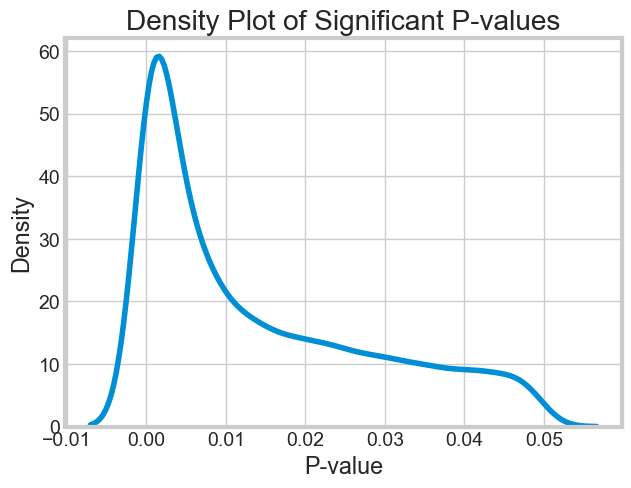

In [37]:
ax = sns.kdeplot(np.array(sig_breast1.pvals))
ax.set(xlabel = 'P-value', title = 'Density Plot of Significant P-values')

As we can see in the density plot, most of the significant p-values are actually very very small, suggesting that our significance level of $\alpha = 0.05$ was more than sufficient. Additionally, it suggests that the majority of our significant genes have a very high level of significance, which is encouraging. 

In [213]:
#Dividing the genes with significant p-vals into tumoral and normal dataframes
sig_breast1_tumors = sig_breast1[['tumoral']]
sig_breast1_normal = sig_breast1[['normal']]

### Working Through 9,039 Significant Genes
We've been given gene information for all the relevant genes. There are clearly different groups by their naming conventins. Let's see if we can sort them.

In [192]:
# get a list of the first few letters of all the genes
first_three_char = [i[:3] for i in gene_exp_difference.gene.values]

# add abbreviations to a dataframe
breast1_abbrevs = breast1_with_pvals
breast1_abbrevs['abbrevs'] = first_three_char

breast1_abbrevs.groupby('abbrevs').count().sort_values(by = 'pvals', ascending = False)

type,tumoral,tumoral,tumoral,tumoral,tumoral,tumoral,tumoral,tumoral,normal,normal,normal,normal,normal,normal,normal,normal,pvals
abbrevs,,,,,,,,,,,,,,,,,
NM_,19860,19860,19860,19860,19860,19860,19860,19860,19860,19860,19860,19860,19860,19860,19860,19860,19860
lin,7405,7405,7405,7405,7405,7405,7405,7405,7405,7405,7405,7405,7405,7405,7405,7405,7405
ENS,2926,2926,2926,2926,2926,2926,2926,2926,2926,2926,2926,2926,2926,2926,2926,2926,2926
A_3,1723,1723,1723,1723,1723,1723,1723,1723,1723,1723,1723,1723,1723,1723,1723,1723,1723
NR_,1638,1638,1638,1638,1638,1638,1638,1638,1638,1638,1638,1638,1638,1638,1638,1638,1638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AI0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
BE8,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
BE9,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


We can see that some types of genes are much more common in the dataset than others. We'll focus on the larger categories of genes

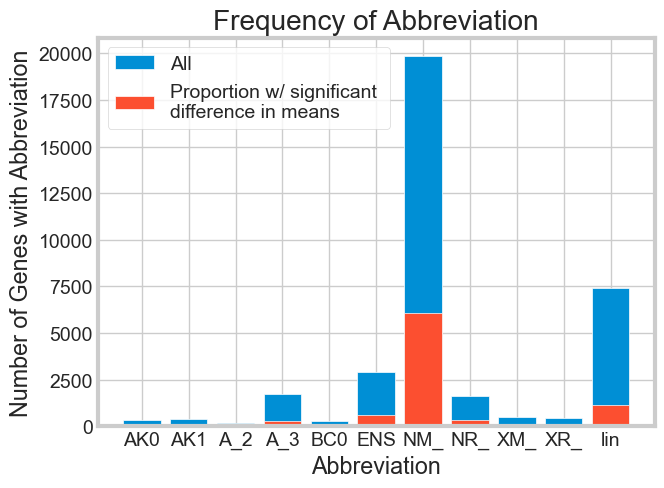

In [193]:
count_breast1_genetypes = breast1_abbrevs.groupby('abbrevs').count()[['pvals']]
count_b1_g100 = count_breast1_genetypes[count_breast1_genetypes.pvals > 100]

count_sig_breast1_genetypes = breast1_abbrevs[breast1_abbrevs.pvals < 0.05].groupby('abbrevs').count()[['pvals']]
count_sig_b1_g100 = count_sig_breast1_genetypes[count_sig_breast1_genetypes.pvals > 100]

plt.bar(count_b1_g100.index, count_b1_g100['pvals'], label = 'All')
plt.bar(count_sig_b1_g100.index, count_sig_b1_g100['pvals'], label = 'Proportion w/ significant \ndifference in means')
plt.xlabel('Abbreviation')
plt.ylabel('Number of Genes with Abbreviation')
plt.title('Frequency of Abbreviation')
plt.legend(loc = 'upper left', fontsize = 14);

It's not especially easy to see from this visualization exactly what proportion the significant genes make up. Let's try a new strategy.

In [194]:
# Let's see if any of the gene abbreviations of the significant genes showed up a disproportionate amount of times
count_sig_b1_g100
count_b1_g100.T[count_sig_b1_g100.index].T
count_big_abbrevs = pd.DataFrame({
    'total': count_b1_g100.T[count_sig_b1_g100.index].T['pvals'],
    'significant': count_sig_b1_g100['pvals']
})

count_big_abbrevs['proportion'] = count_big_abbrevs.apply(lambda x: x['significant']/x['total'], axis = 1)
count_big_abbrevs

,total,significant,proportion
abbrevs,,,
A_2,199,125,0.628141
A_3,1723,308,0.178758
ENS,2926,606,0.207109
NM_,19860,6060,0.305136
NR_,1638,358,0.218559
lin,7405,1132,0.152870


In [787]:
len(sig_breast1)/len(gene_exp_difference)

0.24681885205614112

Alright, so any proportion higher than $\approx$ 24.7% means the significant genes are overrepresented in that category.

In [789]:
#looking at the category of 'A_2' that's so overrepresented in the significant genes
breast1_abbrevs[breast1_abbrevs.abbrevs == 'A_2']

type,tumoral,tumoral,tumoral,tumoral,tumoral,tumoral,tumoral,tumoral,normal,normal,normal,normal,normal,normal,normal,normal,pvals,abbrevs
A_24_P194962,16.18282,16.280511,15.698543,15.634817,15.986371,16.070965,16.255649,16.266498,16.665276,16.840666,16.643748,16.723323,16.56854,16.559773,16.65616,16.727904,0.0000,A_2
A_24_P67408,10.359298,10.524874,10.669421,11.757518,10.594203,12.236854,11.027924,9.848933,10.10365,10.281707,10.139785,9.737081,10.357512,9.844183,10.266159,10.381115,0.0132,A_2
A_24_P33552,16.446302,16.334079,15.705281,15.813235,16.872351,16.43105,16.322988,16.667134,16.764214,16.76161,16.799406,16.759965,16.886216,16.803701,16.987582,16.76161,0.0024,A_2
A_24_P917759,4.699258,5.215004,4.949712,4.540825,4.605027,4.871816,4.563272,4.608338,6.46855,5.199714,5.074599,4.72777,4.714013,4.751052,4.67994,4.438367,0.3872,A_2
A_24_P940477,5.212605,4.608338,4.924866,4.873863,5.273895,5.18703,5.347623,5.00997,5.644763,5.036605,6.328062,4.72777,5.393216,4.940483,4.904911,4.949712,0.3904,A_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A_24_P59247,12.928168,12.698263,11.767387,12.452819,12.298473,12.612493,12.307093,12.161416,13.352556,13.223704,13.622246,13.46889,13.454238,13.334696,13.24933,12.533564,0.0000,A_2
A_24_P153324,13.879352,13.470235,13.836296,13.524878,14.59628,14.469053,13.503167,14.314178,14.771299,14.68011,15.0959,15.031234,15.531082,15.062765,15.009666,14.541543,0.0000,A_2
A_24_P383598,8.567878,8.506164,8.787377,9.394519,8.950906,8.284223,8.653947,7.571242,7.860281,7.77938,8.30033,7.948521,8.127969,7.800666,6.989517,8.109479,0.0064,A_2
A_24_P350307,14.138821,13.933837,13.178046,13.68662,13.688096,14.01752,13.479188,14.302308,14.89231,14.877884,14.787964,15.013692,14.894724,14.614925,15.006675,14.377905,0.0000,A_2


Looking at the data describing all the genes in the dataset from the original study, I was very confused and intrigued to see that many of the genes from A_24 that had come up as significant were genes without descriptions of exactly what they do. 

Searching for a way to find out what they did, I came accross a study that similarly studied the regulation of  genes using microarray data. They also found that many of their significant genes had unknown gene annotations, but they also had a list of genes that they found to be significant. A lot of their genes were 'A_2' genes, so it might be useful to compare the types of genes we found to be significantly different in the test group. Interestingly, their test group was Insulin Resistant Latinos, not breast cancer patients, so I'm curious to see if there's any overlap (Tangen).

In [103]:
pathways = pd.read_csv('pone-0084002-t002.csv')
badlines = []

#some of the data in the csv files contains commas within the descriptions, making those lines impossible to read in
#I'm gonna store them in a list and work through them separately so we don't lose that data 

add_to_list = lambda x: badlines.append(x)
probe_names1 = pd.read_csv('pone-0084002-t003.csv', engine = 'python', on_bad_lines = add_to_list)
probe_names2 = pd.read_csv('pone-0084002-t004.csv', engine = 'python', on_bad_lines = add_to_list)
badlines

[['A_23_P501933',
  'calcium channel',
  ' voltage-dependent',
  ' gamma subunit 6',
  'CACNG6',
  '-1.6'],
 ['A_23_P166297',
  'ATP-binding cassette',
  ' sub-family G',
  ' member 1',
  'ABCG1',
  '-1.5'],
 ['A_23_P132863',
  'LSM3 homolog',
  ' U6 small nuclear RNA associated (S. cerevisiae)',
  'LSM3',
  '+1.7'],
 ['A_23_P145777',
  'NADH dehydrogenase (ubiquinone) 1 alpha subcomplex',
  ' 4',
  ' 9kDa',
  'NDUFA4',
  '+1.6'],
 ['A_23_P65466', 'RAB2B', ' member RAS oncogene family', 'RAB2B', '+1.6'],
 ['A_23_P70843', '2', '3-bisphosphoglycerate mutase', 'BPGM', '+1.5'],
 ['A_32_P123771',
  'ATP synthase',
  ' H+ transporting',
  ' mitochondrial F1 complex',
  ' epsilon subunit',
  'ATP5E',
  '+1.5'],
 ['A_23_P138985', 'CD3d molecule', ' delta (CD3-TCR complex)', 'CD3D', '+1.5'],
 ['A_23_P413796', 'HAUS augmin-like complex', ' subunit 1', 'HAUS1', '+1.5'],
 ['A_23_P87346', 'hemoglobin', ' delta', 'HBD', '+1.5']]

Looking at the `badlines` data, we can see that the 1st, last, and second to last values are consistently unnaffected by the comma issue. The rest of the indices in the lists can just be concatenated together to be the second column of the dataframe.

Additionally, we can see below that `probe_names1` got messed up. We'll need to fix both of these things. `probe_names2` looks ok.

In [71]:
probe_names1.head()

,Probe Name,Gene Description,Gene Symbol,Fold Change
A_24_P208345,solute carrier family 45,member 3,SLC45A3,-2.0
A_23_P10559,apoptosis-associated tyrosine kinase,AATK,-1.6,NaN
A_23_P127948,adrenomedullin,ADM,-1.5,NaN
A_23_P417383,aspartic peptidase,retroviral-like 1,ASPRV1,-1.5
A_23_P4662,B-cell CLL/lymphoma 3,BCL3,-1.5,NaN


In [701]:
# reset index of probe_names1
probe_names1 = probe_names1.reset_index()

In [105]:
probe_names1 = probe_names1.rename(columns = {'Probe Name': 'Also Gene Description','index':'Probe Name'})
probe_names1

,Probe Name,Also Gene Description,Gene Description,Gene Symbol,Fold Change
0,A_24_P208345,solute carrier family 45,member 3,SLC45A3,-2.0
1,A_23_P10559,apoptosis-associated tyrosine kinase,AATK,-1.6,NaN
2,A_23_P127948,adrenomedullin,ADM,-1.5,NaN
3,A_23_P417383,aspartic peptidase,retroviral-like 1,ASPRV1,-1.5
4,A_23_P4662,B-cell CLL/lymphoma 3,BCL3,-1.5,NaN
5,A_23_P359052,biorientation of chromosomes in cell division ...,BOD1L,-1.5,NaN
6,A_23_P210811,CD93 molecule,CD93,-1.5,NaN
7,A_23_P119562,complement factor D (adipsin),CFD,-1.5,NaN
8,A_23_P7144,chemokine (C-X-C motif) ligand 1 (melanoma gro...,alpha),CXCL1,-1.5
9,A_23_P257924,v-ets erythroblastosis virus E26 oncogene homo...,ETS2,-1.5,NaN


In [114]:
# fix columns for those probe_names1 that aren't messed up
good_probe_names1 = probe_names1[probe_names1.isnull()['Fold Change']]
good_probe_names1 = good_probe_names1.drop('Fold Change', axis =1).rename(columns = {'Gene Symbol':'Fold Change',\
                                                        'Gene Description':'Gene Symbol',\
                                                        'Also Gene Description':'Gene Description'})
good_probe_names1

,Probe Name,Gene Description,Gene Symbol,Fold Change
1,A_23_P10559,apoptosis-associated tyrosine kinase,AATK,-1.6
2,A_23_P127948,adrenomedullin,ADM,-1.5
4,A_23_P4662,B-cell CLL/lymphoma 3,BCL3,-1.5
5,A_23_P359052,biorientation of chromosomes in cell division ...,BOD1L,-1.5
6,A_23_P210811,CD93 molecule,CD93,-1.5
7,A_23_P119562,complement factor D (adipsin),CFD,-1.5
9,A_23_P257924,v-ets erythroblastosis virus E26 oncogene homo...,ETS2,-1.5
10,A_23_P99661,hypothetical protein FLJ10357,FLJ10357,-1.5
11,A_23_P67847,UDP-N-acetyl-alpha-D-galactosamine:polypeptide...,GALNT14,-1.5
12,A_23_P110022,GATA binding protein 2,GATA2,-1.5


In [115]:
#find values in probe_names1 that are messed up
bad_probe_names1 = probe_names1[~probe_names1.isnull()['Fold Change']]
bad_probe_names1

,Probe Name,Also Gene Description,Gene Description,Gene Symbol,Fold Change
0,A_24_P208345,solute carrier family 45,member 3,SLC45A3,-2.0
3,A_23_P417383,aspartic peptidase,retroviral-like 1,ASPRV1,-1.5
8,A_23_P7144,chemokine (C-X-C motif) ligand 1 (melanoma gro...,alpha),CXCL1,-1.5
13,A_32_P217750,interleukin 3 receptor,alpha (low affinity),IL3RA,-1.5


In [154]:
# let's make a function to fix the weird data

def fix_data(data):
    '''takes array-like and sorts it into correct categories to match probe_names2, returns 4-column dataframe'''
    
    # initialize the variables we're gonna need
    names = []
    descrip = []
    symbol = []
    fold = []
    
    for i in data:
        names = np.append(names, i[0])
        descrip = np.append(descrip, " ".join(i[1:-2]))
        symbol = np.append(symbol, i[-2])
        fold = np.append(fold, i[-1])
        
    df = pd.DataFrame({
        'Probe Name': names, 'Gene Description': descrip, 'Gene Symbol': symbol, 'Fold Change': fold
    })
        
    return df

In [184]:
#setting up dataframe with all the probes data from the Tangen paper 
probes = pd.concat([good_probe_names1, probe_names2, fix_data(np.array(bad_probe_names1)), fix_data(badlines)])

#some of the fold changes ended up being strings, so let's fix that 
probes['Fold Change'] = [float(i) for i in probes['Fold Change']]

probes = probes.sort_values(by='Fold Change').reset_index().drop('index', axis=1)
probes

,Probe Name,Gene Description,Gene Symbol,Fold Change
0,A_24_P208345,solute carrier family 45 member 3,SLC45A3,-2.0
1,A_23_P10559,apoptosis-associated tyrosine kinase,AATK,-1.6
2,A_23_P501933,calcium channel voltage-dependent gamma subu...,CACNG6,-1.6
3,A_23_P417383,aspartic peptidase retroviral-like 1,ASPRV1,-1.5
4,A_23_P7144,chemokine (C-X-C motif) ligand 1 (melanoma gro...,CXCL1,-1.5
...,...,...,...,...
85,A_24_P152753,ribosomal protein L31 pseudogene 18,RPL31P18,2.1
86,A_32_P196483,ribosomal protein S3A pseudogene 5,RPS3A,2.2
87,A_32_P31182,ribosomal protein L7 pseudogene 26,RPL7,2.2
88,A_24_P6975,ribosomal protein L34 pseudogene 34,RPL34P34,2.2


In [206]:
common_sig_genes = pd.merge(probes, sig_breast1.reset_index(), left_on = 'Probe Name', right_on = 'index')
common_sig_genes

,Probe Name,Gene Description,Gene Symbol,Fold Change,index,tumoral,tumoral,tumoral,tumoral,tumoral,...,tumoral,normal,normal,normal,normal,normal,normal,normal,normal,pvals
0,A_23_P258108,ribosomal protein L9 pseudogene 16,RPL9P16,1.6,A_23_P258108,16.792926,16.67444,16.40395,16.632233,16.464693,...,16.989618,17.165941,17.296524,17.327932,17.250083,17.296524,17.314751,17.254242,17.100101,0.0000
1,A_24_P153324,ribosomal protein L7 pseudogene 44,RPL7P44,1.7,A_24_P153324,13.879352,13.470235,13.836296,13.524878,14.59628,...,14.314178,14.771299,14.68011,15.0959,15.031234,15.531082,15.062765,15.009666,14.541543,0.0000
2,A_24_P375849,ribosomal protein S17 pseudogene 2,RPS17P2,1.7,A_24_P375849,15.509348,15.332738,15.073944,14.776201,15.534887,...,16.050295,15.723349,15.920386,16.20088,16.030253,16.315761,16.044399,16.140329,15.828284,0.0012
3,A_24_P84808,ribosomal protein L7 pseudogene 50,RPL7P50,1.7,A_24_P84808,16.20088,15.920386,16.15244,15.572198,16.684827,...,16.070965,16.70397,16.676326,16.771906,16.894067,16.813405,16.669264,16.643748,16.385257,0.0008
4,A_24_P349636,ribosomal protein L7 pseudogene 48,RPL7P48,1.7,A_24_P349636,16.6294,16.283245,16.563445,16.268841,17.032514,...,16.576824,17.090527,16.984382,17.086771,17.224427,17.062445,17.02927,17.103624,16.903069,0.0004
5,A_24_P161914,ribosomal protein L7 pseudogene 13,RPL7P13,1.8,A_24_P161914,12.463403,11.9606,12.31498,12.039806,12.97639,...,12.683576,13.096848,13.003879,13.690489,13.250511,13.786904,13.355295,13.565866,13.063526,0.0004
6,A_24_P366165,ribosomal protein L26 pseudogene 12,RPL26P12,1.8,A_24_P366165,15.745519,15.543668,14.77986,14.841871,15.199165,...,15.877977,16.15244,16.229911,16.597562,16.320219,16.665276,16.167118,16.305715,15.913231,0.0000
7,A_24_P186944,ribosomal protein L9 pseudogene 18,RPL9P18,1.9,A_24_P186944,16.162879,16.082685,15.580511,15.909983,15.766005,...,16.492392,16.822276,16.886216,16.780382,16.806969,17.000483,16.819267,16.822276,16.495329,0.0000
8,A_24_P76358,ribosomal protein S3a pseudogene 36,RPS3AP36,2.0,A_24_P76358,14.427781,14.257595,13.608915,13.795865,13.911406,...,14.916304,14.918896,14.777375,15.085834,14.774796,15.413394,14.99652,15.171359,14.649424,0.0016


In [207]:
#seeing how other pathways compare
pathways

,KEGG Pathway,Probe Count,Up Regulated,Down Regulated,Significance
0,Ribosome,119,119,0,<0.0001
1,Oxidative Phosphorylation,32,28,4,<0.0001
2,Alzheimer Disease,31,22,9,<0.01
3,Epithelial Cell Signaling,15,1,14,<0.01
4,Huntington Disease,29,23,6,<0.05
5,Systemic Lupus Erythematosus,31,1,30,<0.05
6,Parkinson Disease,23,22,1,<0.05
7,Endocytosis,28,0,28,≤0.05
8,MAPK Signaling,36,0,36,0.057


Very interestingly, the datasets have nine genes that were found to be significantly different in expression in the test groups versus the controls. Also, all nine of them, 100%, were found to be ribosomal protein pseudogenes. This is especially intriguing given that the two studies were looking at very different diseases. Both datasets found that these ribosome genes were quite significantly different. Finally, all of the ribosome genes were upregulated in the Insulin Resistant Latinos dataset (Tangen). My data does not record whether or not the gene was downregulated or upregulated in the disease group, so let's see if that holds true in the cancer patients. 

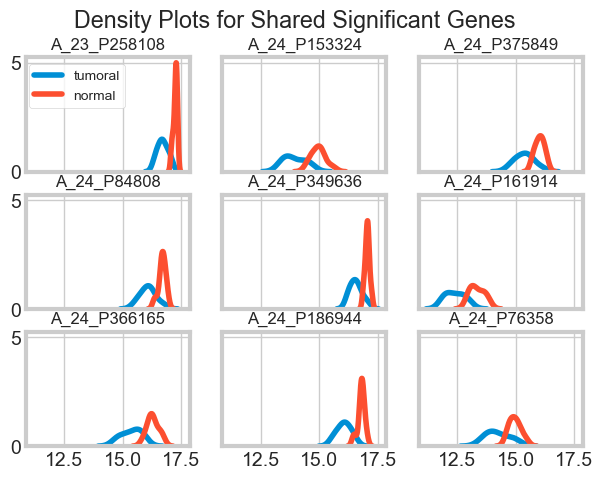

In [366]:
fig, axes = plt.subplots(3,3, sharex=True, sharey=True)
num_genes = 0

for i in range(3):
    for j in range(3):
        gene = common_sig_genes['Probe Name'][num_genes]
        sns.kdeplot(ax = axes[i,j],x = sig_breast1_tumors.T[gene], label = 'tumoral')
        sns.kdeplot(ax = axes[i,j],x = sig_breast1_normal.T[gene], label = 'normal')
        axes[i,j].set_title(gene, fontsize = '12')
    
        axes[i,j].set(xlabel = None, ylabel = None)
        num_genes += 1

plt.suptitle('Density Plots for Shared Significant Genes')
plt.legend(bbox_to_anchor = (-1.75,3.4), fontsize = 10);

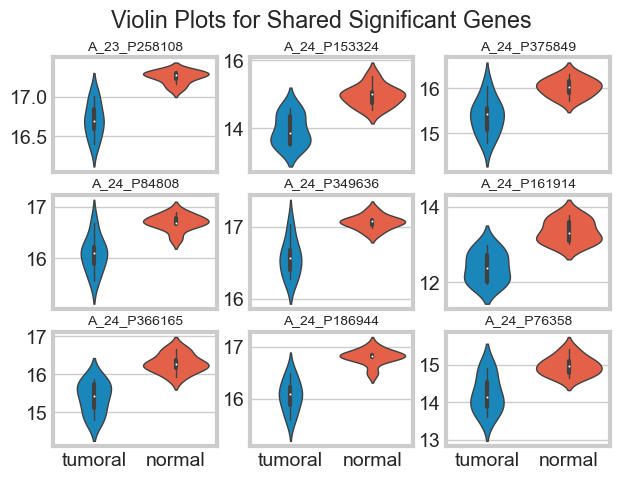

In [646]:
common_tumors = breast1_tumors.set_index('gene').T[common_sig_genes['Probe Name']]
common_normal = breast1_normal.set_index('gene').T[common_sig_genes['Probe Name']]

fig, ax = plt.subplots(3,3, sharex = True)
plt.suptitle('Violin Plots for Shared Significant Genes')
count = 0

for i in range(3):
    for j in range(3):
        sns.violinplot([common_tumors.iloc[:,count], common_normal.iloc[:,count]], ax = ax[i,j], linewidth = 1, xticks = False)
        ax[i,j].set_title(common_tumors.iloc[:,count].name, fontsize = 10)
        ax[i,j].set_xticks(ticks = [0,1],labels = ['tumoral', 'normal'])
        count += 1
    

Interestingly, it looks like all of the shared significant genes were downregulated in the cancer data, as compared to upregulated in the insulin resistance data. I would be very curious to see if ribosomal genes had any more interesting trends in the cancer data.

I found a set of ribosomal genes from the HUGO Gene Nomenclature Committee with the University of Cambridge. Let's see if we can find any common ground with the datasets generated here. 

In [398]:
ribosomal = pd.read_csv('ribosomal.txt', sep='\t')
ribosomal.head()

,HGNC ID,Approved symbol,Approved name,Status,Locus type,Previous symbols,Alias symbols,Chromosome,NCBI Gene ID,Ensembl gene ID,Vega gene ID,Group ID,Group name
0,HGNC:10298,RPL10,ribosomal protein L10,Approved,gene with protein product,NaN,"NOV, QM, DXS648E, DXS648, FLJ23544, L10, uL16",Xq28,6134,ENSG00000147403,OTTHUMG00000033189,729,L ribosomal proteins
1,HGNC:10299,RPL10A,ribosomal protein L10a,Approved,gene with protein product,NEDD6,"Csa-19, L10A, uL1",6p21.31,4736,ENSG00000198755,OTTHUMG00000014566,729,L ribosomal proteins
2,HGNC:17976,RPL10L,ribosomal protein L10 like,Approved,gene with protein product,NaN,NaN,14q21.2,140801,ENSG00000165496,OTTHUMG00000157869,729,L ribosomal proteins
3,HGNC:10301,RPL11,ribosomal protein L11,Approved,gene with protein product,NaN,"L11, uL5",1p36.11,6135,ENSG00000142676,OTTHUMG00000002926,729,L ribosomal proteins
4,HGNC:10302,RPL12,ribosomal protein L12,Approved,gene with protein product,NaN,"L12, uL11",9q33.3,6136,ENSG00000197958,OTTHUMG00000020704,729,L ribosomal proteins


Unfortunately, this dataset does not have the same gene name format as in my dataset. From the same HUGO Gene Nomenclature Committee, I got a complete set of HGNC IDs with all the other information and naming conventions to compare it to. 

In [410]:
complete = pd.read_csv('hgnc_complete_set.tsv', sep='\t', dtype = object, usecols = ['hgnc_id','name','locus_group','refseq_accession'])
complete.head()

,hgnc_id,name,locus_group,refseq_accession
0,HGNC:5,alpha-1-B glycoprotein,protein-coding gene,NM_130786
1,HGNC:37133,A1BG antisense RNA 1,non-coding RNA,NR_015380
2,HGNC:24086,APOBEC1 complementation factor,protein-coding gene,NM_014576
3,HGNC:7,alpha-2-macroglobulin,protein-coding gene,NM_000014
4,HGNC:27057,A2M antisense RNA 1,non-coding RNA,NR_026971


In [416]:
ribosomal_with_refseq = pd.merge(ribosomal, complete, left_on = 'HGNC ID', right_on = 'hgnc_id')
print(len(ribosomal) == len(ribosomal_with_refseq))
print(sum(ribosomal_with_refseq.refseq_accession.isnull()))
ribosomal_with_refseq.head()

True
0


,HGNC ID,Approved symbol,Approved name,Status,Locus type,Previous symbols,Alias symbols,Chromosome,NCBI Gene ID,Ensembl gene ID,Vega gene ID,Group ID,Group name,hgnc_id,name,locus_group,refseq_accession
0,HGNC:10298,RPL10,ribosomal protein L10,Approved,gene with protein product,NaN,"NOV, QM, DXS648E, DXS648, FLJ23544, L10, uL16",Xq28,6134,ENSG00000147403,OTTHUMG00000033189,729,L ribosomal proteins,HGNC:10298,ribosomal protein L10,protein-coding gene,NM_006013
1,HGNC:10299,RPL10A,ribosomal protein L10a,Approved,gene with protein product,NEDD6,"Csa-19, L10A, uL1",6p21.31,4736,ENSG00000198755,OTTHUMG00000014566,729,L ribosomal proteins,HGNC:10299,ribosomal protein L10a,protein-coding gene,NM_007104
2,HGNC:17976,RPL10L,ribosomal protein L10 like,Approved,gene with protein product,NaN,NaN,14q21.2,140801,ENSG00000165496,OTTHUMG00000157869,729,L ribosomal proteins,HGNC:17976,ribosomal protein L10 like,protein-coding gene,NM_080746
3,HGNC:10301,RPL11,ribosomal protein L11,Approved,gene with protein product,NaN,"L11, uL5",1p36.11,6135,ENSG00000142676,OTTHUMG00000002926,729,L ribosomal proteins,HGNC:10301,ribosomal protein L11,protein-coding gene,NM_000975
4,HGNC:10302,RPL12,ribosomal protein L12,Approved,gene with protein product,NaN,"L12, uL11",9q33.3,6136,ENSG00000197958,OTTHUMG00000020704,729,L ribosomal proteins,HGNC:10302,ribosomal protein L12,protein-coding gene,NM_000976


As we can see, we didn't lose any length in the merge, so all of the ribosomal genes have an equivalent in the complete dataset. Additionally, there aren't any null values in `refseq_accession` so we should have a name for all of the ribosomal genes.

Let's start by seeing how many are present in the original dataset `breast1`.

In [803]:
genes = ribosomal_with_refseq.refseq_accession.values
genes_in_breast1 = []

for i in genes:
    try:
        breast1[i]
        genes_in_breast1 = np.append(genes_in_breast1, i)
    except:
        p = 3 #just need a statement to avoid an error

len(genes_in_breast1)

204

204 of the 247 ribosomal genes are in breast1. How many of those ended up being significant?

In [479]:
# find intersection 
sig_ribosomal_genes = np.intersect1d(sig_breast1.index.values, genes_in_breast1)
len(sig_ribosomal_genes)/len(genes_in_breast1)

0.4264705882352941

42.6%, or 87/204, of the ribosomal genes that were in `breast1` ended up being significantly different between the two groups. Overall, only 24.7% of genes in the original dataset were found to be significantly different between the two groups. Ribosomal genes have a much higher rate of significance than the expected value of 24.7%. 

In [484]:
print('Mean p-value of Significant Ribosomal Genes:', np.mean(sig_breast1.loc[sig_ribosomal_genes].pvals))
print('Max p-value of Significant Ribosomal Genes:', np.max(sig_breast1.loc[sig_ribosomal_genes].pvals))
print('Median p-value of Significant Ribosomal Genes:', np.median(sig_breast1.loc[sig_ribosomal_genes].pvals))

Mean p-value of Significant Ribosomal Genes: 0.005935632183908046
Max p-value of Significant Ribosomal Genes: 0.0476
Median p-value of Significant Ribosomal Genes: 0.0004


The average pvalue of the ribosomal genes was 0.0059, well below the significance level. Although the maximum p-value was 0.0476, the median was 0.0004, suggesting a right-skewed distribution and that most of the p-values are very significant. 

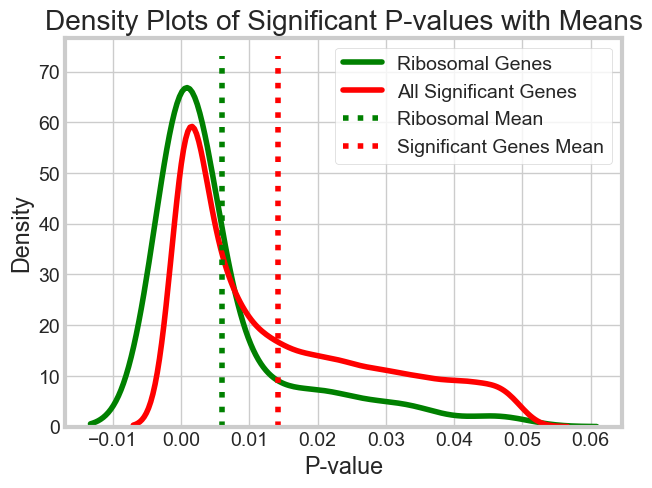

In [543]:
#graphing ribosomal p-values against all of the p-values to compare 
ax = sns.kdeplot(sig_breast1.loc[sig_ribosomal_genes].pvals, label = 'Ribosomal Genes', color = 'green')
ax = sns.kdeplot(sig_breast1.pvals, label = 'All Significant Genes', color = 'red')
ax.set(xlabel = 'P-value', title = 'Density Plots of Significant P-values with Means')

plt.vlines(np.mean(sig_breast1.loc[sig_ribosomal_genes].pvals), 0, 73, ls = ':', \
          color = 'green', label = 'Ribosomal Mean')
plt.vlines(np.mean(sig_breast1.pvals), 0, 73, ls = ':', \
          color = 'red', label = 'Significant Genes Mean')
plt.legend();

We can see from the density plot that the average p-value of the significant ribosomal genes is less than that of all the significant genes, that there are comparatively more very small p-values in the significant ribosomal genes, and that there are fewer p-values at the higher end of the significance cutoff than for all significant genes. 

In [1026]:
diff_ribosomal = pd.DataFrame(sig_breast1_normal.apply('mean', axis=1)-sig_breast1_tumors.apply('mean', axis=1)).loc[sig_ribosomal_genes]
diff_ribosomal[diff_ribosomal[0]<0]

,0
NM_002949,-0.470801
NM_014763,-0.264348
NM_015971,-0.502782
NM_016640,-0.56694
NM_023936,-0.529067
NM_032111,-0.382393
NM_198486,-0.335152


We can see that for both ribosomal protein pseudogenes and ribosomal proteins, they have a higher likelihood of being significantly different in cancer patients than health ones. Additonally, they tend to have more significant p-values than the general population of significant genes. Also, the ribosomal genes are much more likely to be downregulated in tumor patients than the alternative. All 9 of the ribosomal pseudogenes were downregulated, and of the 87 ribosomal protein genes studied that came up with a significant p-pvalue, 80 of them had a higher gene expression in the normal group as opposed to the tumoral group. Only seven of the significant ribosomal genes had higher expression in the tumoral group. Although this is only a pattern and not an explanation or discovery, it is still interesting how strong the pattern is, and I'm very curious about the reason for it. 

In [1015]:
yes = 0
count = 1

while yes==0:
    sample = breast1_with_pvals.sample()
    name = sample.iloc[0].name
    pval = sample['pvals'][0]
    print('Name of gene:', name)
    print('Pvalue for gene:', pval)
    if name in ribosomal_with_refseq.refseq_accession.values:
        print(name, 'is a ribosomal gene protein product.')
        yes = 1
    elif pval == 0:
        print(name, 'is very significantly different between the two groups.')
        yes = 1
    else:
        count += 1
    print('\n')

if count == 1:
    print('It only took', count, 'try to get a highly significant gene or a ribosomal gene protein product!!')
else:
    print('It took', count, 'tries to get a highly significant gene or a ribosomal gene protein product.')

Name of gene: NM_003296
Pvalue for gene: 0.3324


Name of gene: lincRNA:chr15:58549646-58623578_F
Pvalue for gene: 0.0892


Name of gene: NM_145725
Pvalue for gene: 0.1012


Name of gene: XM_001718042
Pvalue for gene: 0.0152


Name of gene: AK098314
Pvalue for gene: 0.9228


Name of gene: NM_018073
Pvalue for gene: 0.0
NM_018073 is very significantly different between the two groups.


It took 6 tries to get a highly significant gene or a ribosomal gene protein product.


### Bibliography

Tangen SE, Tsinajinnie D, Nuñez M, Shaibi GQ, Mandarino LJ, Coletta DK (2013) Whole Blood Gene Expression Profiles in Insulin Resistant Latinos with the Metabolic Syndrome. PLoS ONE 8(12): e84002. https://doi.org/10.1371/journal.pone.0084002

“Gene Group | HUGO Gene Nomenclature Committee.” www.genenames.org, www.genenames.org/data/genegroup/#!/group/1054.

Feltes, B.C.; Chandelier, E.B.; Grisci, B.I.; Dorn, M. CuMiDa: An Extensively Curated Microarray Database for Benchmarking and Testing of Machine Learning Approaches in Cancer Research. Journal of Computational Biology, 2019. https://sbcb.inf.ufrgs.br/cumida 